# Nonuniformly Sampled Trivariate EMD (NS-TEMD)

**NS-TEMD** (Hemakom, Ahrabian, Looney, Rehman & Mandic, ICASSP 2015)
extends trivariate / multivariate EMD to data with **power imbalance**
and **inter-channel correlation**.

Classical **EMD** sifts each channel on its own. Extrema are 1-D, so a
shared 4 Hz oscillation can land in IMF 2 on channel 0 and IMF 3 on
channel 1 (**mode misalignment**). **MEMD / TEMD** fix that by projecting
the vector signal onto a **uniform** Hammersley net on the 2-sphere and
sifting a *common* local mean. That net is wasteful when the cloud of
samples is a thin ellipsoid: most directions look at noise.

NS-TEMD keeps MEMD's sifting loop and changes the **projection geometry**:

1. PCA of the input covariance (MATLAB `princomp`, computed **once**);
2. map Hammersley angles onto an ellipsoid with axes \(\lambda_i^{1/3}\),
   re-normalise, rotate by the eigenvectors \(V\);
3. estimate the local mean from **both** that nonuniform set **and** the
   original uniform Hammersley set (paper Algorithm 1).

Total projections are therefore \(2 n_{\mathrm{dir}}\). The MATLAB header
asks that NS-TEMD's `n_dir` be **half** the MEMD count used in a fair
comparison. PySDKit still defaults to 64, matching `nstemd.m`.

| | **EMD** | **MEMD / TEMD** | **NS-TEMD** (this notebook) |
|---|---|---|---|
| Input | `(T,)` per channel | `(C, T)`, typically \(C=3\) | `(C, T)`, \(3 \le C \le 16\) |
| Local mean | 1-D spline envelopes | mean of *uniform* projections | uniform **+ PCA ellipsoid** |
| Mode alignment | no | yes | yes |
| Unbalanced channels | n/a | needs large `n_dir` | designed for this |

**Reference**

> A. Hemakom, A. Ahrabian, D. Looney, N. Rehman and D. P. Mandic.
> *Nonuniformly sampled trivariate empirical mode decomposition.*
> IEEE ICASSP, 2015.

MATLAB: `repo/NSTEMD/nstemd.m`.


## 1. Imports


In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from pysdkit import NSTEMD, MEMD, EMD
from pysdkit._emd.nstemd import princomp, ellipsoid_directions

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(NSTEMD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Nonuniformly Sampled Trivariate Empirical Mode Decomposition (NS-TEMD)


## 2. Uniform sphere vs PCA ellipsoid (paper Figure 1)

MEMD samples the 2-sphere uniformly. NS-TEMD warps those angles through
an ellipsoid aligned with the data covariance, then puts the points back
on the sphere. The second half of the projection set is the original
Hammersley net, so directions of high curvature that the ellipsoid
misses are still used.


In [ ]:
rng = np.random.default_rng(1)
residue = np.column_stack(
    [
        4.0 * rng.standard_normal(800),
        0.25 * rng.standard_normal(800),
        0.25 * rng.standard_normal(800),
    ]
)
coeff, latent = princomp(residue)
print("eigenvalues", np.round(latent, 3))
print("PC1", np.round(coeff[:, 0], 3))

n_dir = 32
nstemd = NSTEMD(n_dir=n_dir)
seq = nstemd.init_hammersley(3)
uniform = nstemd.direction_vectors(3)
ellip = ellipsoid_directions(seq, coeff, latent)
both = nstemd.projection_directions(seq, 3, coeff, latent)
print("uniform", uniform.shape, "ellipsoid", ellip.shape, "union", both.shape)
print(
    "mean |<d, PC1>|  uniform / ellipsoid:",
    np.mean(np.abs(uniform @ coeff[:, 0])),
    np.mean(np.abs(ellip @ coeff[:, 0])),
)

eigenvalues [15.487  0.068  0.06 ]
PC1 [-1.     0.002 -0.003]
uniform (32, 3) ellipsoid (32, 3) union (64, 3)
mean |<d, PC1>|  uniform / ellipsoid: 0.48628645720724534 0.8363284747514645


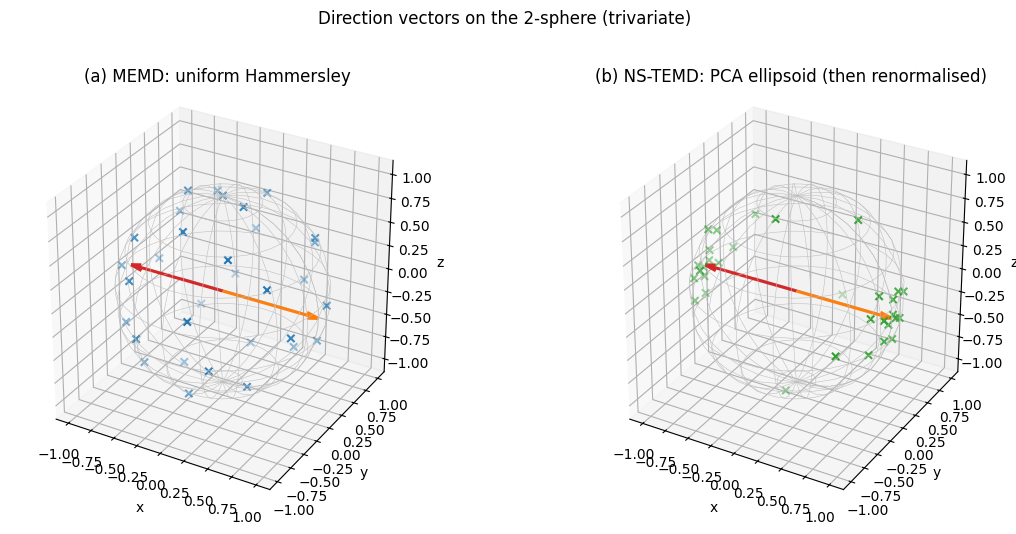

In [ ]:
def _draw_sphere(ax, pts, title, pc=None, color="C0"):
    u = np.linspace(0.0, 2.0 * np.pi, 36)
    v = np.linspace(0.0, np.pi, 18)
    xs = np.outer(np.cos(u), np.sin(v)).T
    ys = np.outer(np.sin(u), np.sin(v)).T
    zs = np.outer(np.ones_like(u), np.cos(v)).T
    ax.plot_wireframe(xs, ys, zs, color="0.75", linewidth=0.4, rstride=2, cstride=2)
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=color, marker="x", s=28)
    if pc is not None:
        origin = np.zeros(3)
        ax.quiver(*origin, *pc, color="C3", lw=2.2, arrow_length_ratio=0.12)
        ax.quiver(*origin, *(-pc), color="C1", lw=2.2, arrow_length_ratio=0.12)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_box_aspect((1, 1, 1))


pc1 = coeff[:, 0]
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
_draw_sphere(ax0, uniform, "(a) MEMD: uniform Hammersley", pc=pc1, color="C0")
_draw_sphere(
    ax1, ellip, "(b) NS-TEMD: PCA ellipsoid (then renormalised)", pc=pc1, color="C2"
)
fig.suptitle("Direction vectors on the 2-sphere (trivariate)", y=1.02)
plt.tight_layout()
plt.show()

## 3. What changes relative to EMD

Univariate EMD interpolates extrema of \(x(t)\) itself. In \(\mathbb{R}^3\)
there is no total order, so NS-TEMD never looks for vector maxima.
A projection \(y_k(t) = \langle s(t), d_k \rangle\) is scalar; its extrema
mark times at which the *multivariate* envelopes are interpolated, then
averaged. All three channels therefore share IMF indices.

The only geometric extra versus MEMD is the ellipsoid map of Algorithm 1.
Unlike APIT-MEMD, PCA is **global** (the original record), not recomputed
on every residue, and the uniform net is **kept** rather than discarded.


## 4. Power-imbalanced trivariate tones: EMD vs NS-TEMD

Channel 0 is ten times stronger than the others (the ICASSP setting).
A shared 4 Hz tone should occupy the **same IMF index** on every channel
after NS-TEMD. Per-channel EMD typically does not keep that alignment.


In [ ]:
n_samples = 400
fs = 200.0
t = np.arange(n_samples) / fs
shared = np.cos(2 * np.pi * 4 * t)
ch0 = 10.0 * (shared + 0.4 * np.cos(2 * np.pi * 18 * t))
ch1 = 0.8 * shared + 0.5 * np.sin(2 * np.pi * 11 * t)
ch2 = 0.5 * shared + 0.7 * np.cos(2 * np.pi * 18 * t)
signal = np.vstack([ch0, ch1, ch2])

nstemd = NSTEMD(n_dir=16, max_iter=200)
imfs = nstemd.fit_transform(signal)
err = np.max(np.abs(imfs.sum(axis=0).T - signal))
print("NS-TEMD IMFs", imfs.shape, "recon max abs error", err)
print("PCA eigenvalues", np.round(nstemd.eig_val_, 4))

emd = EMD()
emd_imfs = [emd.fit_transform(signal[c]) for c in range(3)]
print("per-channel EMD IMF counts", [a.shape[0] for a in emd_imfs])

NS-TEMD IMFs (3, 400, 3) recon max abs error 2.220446049250313e-16
PCA eigenvalues [58.6855  0.2144  0.0626]
per-channel EMD IMF counts [4, 5, 5]


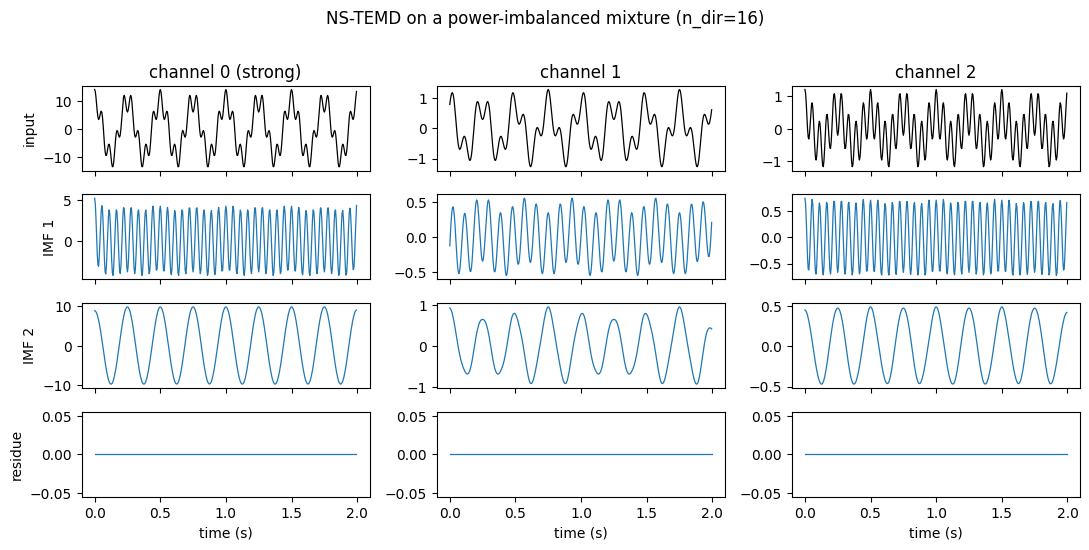

In [ ]:
n_imfs = imfs.shape[0]
fig, axes = plt.subplots(n_imfs + 1, 3, figsize=(11, 1.35 * (n_imfs + 1)), sharex=True)
labels = ["channel 0 (strong)", "channel 1", "channel 2"]
for c in range(3):
    axes[0, c].plot(t, signal[c], color="k", lw=0.9)
    axes[0, c].set_title(labels[c])
    if c == 0:
        axes[0, c].set_ylabel("input")
    for k in range(n_imfs):
        axes[k + 1, c].plot(t, imfs[k, :, c], lw=0.9)
        if c == 0:
            ylab = "residue" if k == n_imfs - 1 else "IMF {}".format(k + 1)
            axes[k + 1, c].set_ylabel(ylab)
        if k == n_imfs - 1:
            axes[k + 1, c].set_xlabel("time (s)")
fig.suptitle("NS-TEMD on a power-imbalanced mixture (n_dir=16)", y=1.01)
plt.tight_layout()
plt.show()

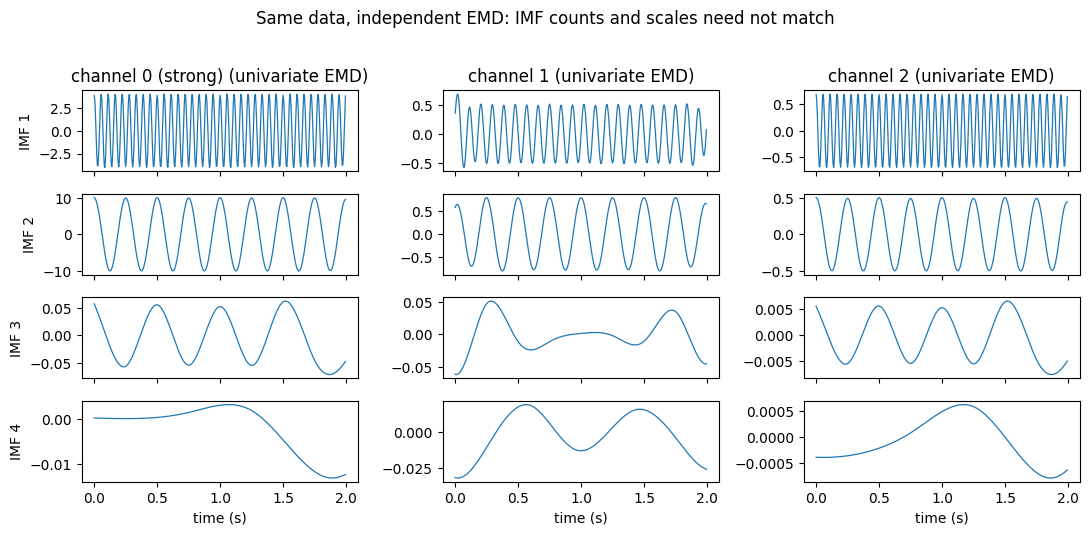

In [ ]:
k_show = min(4, min(a.shape[0] for a in emd_imfs))
fig, axes = plt.subplots(k_show, 3, figsize=(11, 1.3 * k_show), sharex=True)
for c in range(3):
    for k in range(k_show):
        axes[k, c].plot(t, emd_imfs[c][k], lw=0.9)
        if c == 0:
            axes[k, c].set_ylabel("IMF {}".format(k + 1))
        if k == 0:
            axes[k, c].set_title(labels[c] + " (univariate EMD)")
        if k == k_show - 1:
            axes[k, c].set_xlabel("time (s)")
fig.suptitle("Same data, independent EMD: IMF counts and scales need not match", y=1.02)
plt.tight_layout()
plt.show()

## 5. Practical notes

- **`n_dir`.**  Envelope averaging uses `2 * n_dir` projections.  To
  compare with MEMD at 64 directions, pass `n_dir=32` to `NSTEMD`.
  MATLAB default is still 64.  Minimum is 6.
- **PCA.**  Computed once on the original record (`princomp`), not on
  each residue (that adaptive relocation is APIT-MEMD).
- **Channels.**  The ellipsoid map is for \(C=3\).  For 4–16 channels
  MATLAB falls back to a doubled uniform Hammersley net.
- **Stop criteria.**  `"stop"` and `"fix_h"` are the same as MEMD.
- **Reconstruction.**  Summing IMFs along axis 0, including the residue,
  recovers the (oriented) input.
